In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import confusion_matrix as cm
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.metrics import classification_report

In [2]:
# Set Dataset Paths
train_path = r"C:\Project_5\Dataset\images.cv_jzk6llhf18tm3k0kyttxz\data\train"
test_path = r"C:\Project_5\Dataset\images.cv_jzk6llhf18tm3k0kyttxz\data\test"
val_path = r"C:\Project_5\Dataset\images.cv_jzk6llhf18tm3k0kyttxz\data\val"

In [3]:
# Image Transformers
train_transform = transforms.Compose([transforms.Resize((224,224)),transforms.RandomHorizontalFlip(),
transforms.RandomRotation(10),transforms.ToTensor(),transforms.Normalize ([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])])

In [4]:
test_val_transform = transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize ([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])])

In [5]:
# Load Datasets
train_dataset = datasets.ImageFolder(train_path,transform = train_transform)
test_dataset = datasets.ImageFolder(test_path,transform = test_val_transform)
val_dataset = datasets.ImageFolder(val_path,transform = test_val_transform )

In [6]:
# Creating DataLoders
train_loader = DataLoader(train_dataset,batch_size=32,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle = False)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle = False)

In [7]:
print("Train:", len(train_dataset))
print("Test:", len(test_dataset))
print("Val:", len(val_dataset))


Train: 6225
Test: 3187
Val: 1092


In [8]:
# How many classes are there in our tairning Dataset
num_classes = len(train_dataset.classes)
Fish_label = train_dataset.classes
print(Fish_label)
print(num_classes)


['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']
11


In [ ]:
# Building a  CNN model from scratch.
class CNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        # Convolution Layer
        self.conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1,stride=1)
        self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1,stride=1)
        self.conv3 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1,stride=1)
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)

        # Fully Connected Layer
        self.fc1 = nn.Linear(in_features= 128*28*28, out_features= 512)
        self.fc2 = nn.Linear(in_features=512,out_features=11)

    # Feed Forward    
    def forward(self,x):
        convolution_layer1 = self.pool(torch.relu(self.conv1(x)))
        convolution_layer2 = self.pool(torch.relu(self.conv2(convolution_layer1)))
        convolution_layer3 = self.pool(torch.relu(self.conv3(convolution_layer2)))
        flatten_layer = convolution_layer3.view(-1,128*28*28)
        fully_connected_layer_1 = torch.relu(self.fc1(flatten_layer))
        fully_connected_layer_2 = self.fc2(fully_connected_layer_1)
        return fully_connected_layer_2
    
model = CNN(num_classes)
# Defining Loss Function
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)

# Training
epochs = 2
for epoch in range(epochs):
  for images_as_tensor_values, actual_labels in train_loader:
      optimizer.zero_grad()
      predicted_labels = model(images_as_tensor_values) # predicted_labels=0-9
      loss = criterion(predicted_labels, actual_labels)
      loss.backward()
      optimizer.step()
  print('Epoch = ', epoch, 'Loss = ', loss.item())
      

Epoch =  0 Loss =  0.32291340827941895
Epoch =  1 Loss =  0.23907005786895752


In [ ]:
# Testing and Evaluation for Accuracy
test_correct = 0
test_total = 0
with torch.no_grad():
    for image,label in test_loader:
        outputs = model(image)
        _, predicted_labels = torch.max(outputs.data,1)
        
        test_total += label.size(0)
        test_correct += (predicted_labels == label).sum().item()

test_accuracy = 100 * test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.2f}%")

        

Test Accuracy: 92.50%


In [13]:
# pretrained model VGG16
model = models.vgg16(pretrained = True)
for i in model.features.parameters():
    i.requires_grad = False # Freeze
# modify the last layer of VGG16
model.classifier[6] = nn.Linear(4096,num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
# Training
epochs = 2
for epoch in range(epochs):
  for images_as_tensor_values, actual_labels in train_loader:
      optimizer.zero_grad()
      predicted_labels = model(images_as_tensor_values) # predicted_labels=0-9
      loss = criterion(predicted_labels, actual_labels)
      loss.backward()
      optimizer.step()
  print('Epoch = ', epoch, 'Loss = ', loss.item())

C:\Users\D E L L\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\D E L L\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch =  0 Loss =  0.9148651957511902
Epoch =  1 Loss =  1.3159393072128296


In [14]:
# Evaluation for pretrained model VGG16
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)
        _,predicted = torch.max(outputs,1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())


In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=Fish_label
))

                                  precision    recall  f1-score   support

                     animal fish       0.95      1.00      0.97       520
                animal fish bass       0.50      0.15      0.24        13
   fish sea_food black_sea_sprat       0.99      0.94      0.96       298
   fish sea_food gilt_head_bream       0.71      0.99      0.83       305
   fish sea_food hourse_mackerel       0.90      1.00      0.95       286
        fish sea_food red_mullet       0.98      0.96      0.97       291
     fish sea_food red_sea_bream       0.99      0.95      0.97       273
          fish sea_food sea_bass       0.99      0.67      0.80       327
            fish sea_food shrimp       1.00      0.98      0.99       289
fish sea_food striped_red_mullet       0.96      0.91      0.93       293
             fish sea_food trout       1.00      0.97      0.98       292

                        accuracy                           0.93      3187
                       macro avg    

Accuracy : 0.9337935362409789
confusion_matrix : <function confusion_matrix at 0x000002B5B67C3EC0>


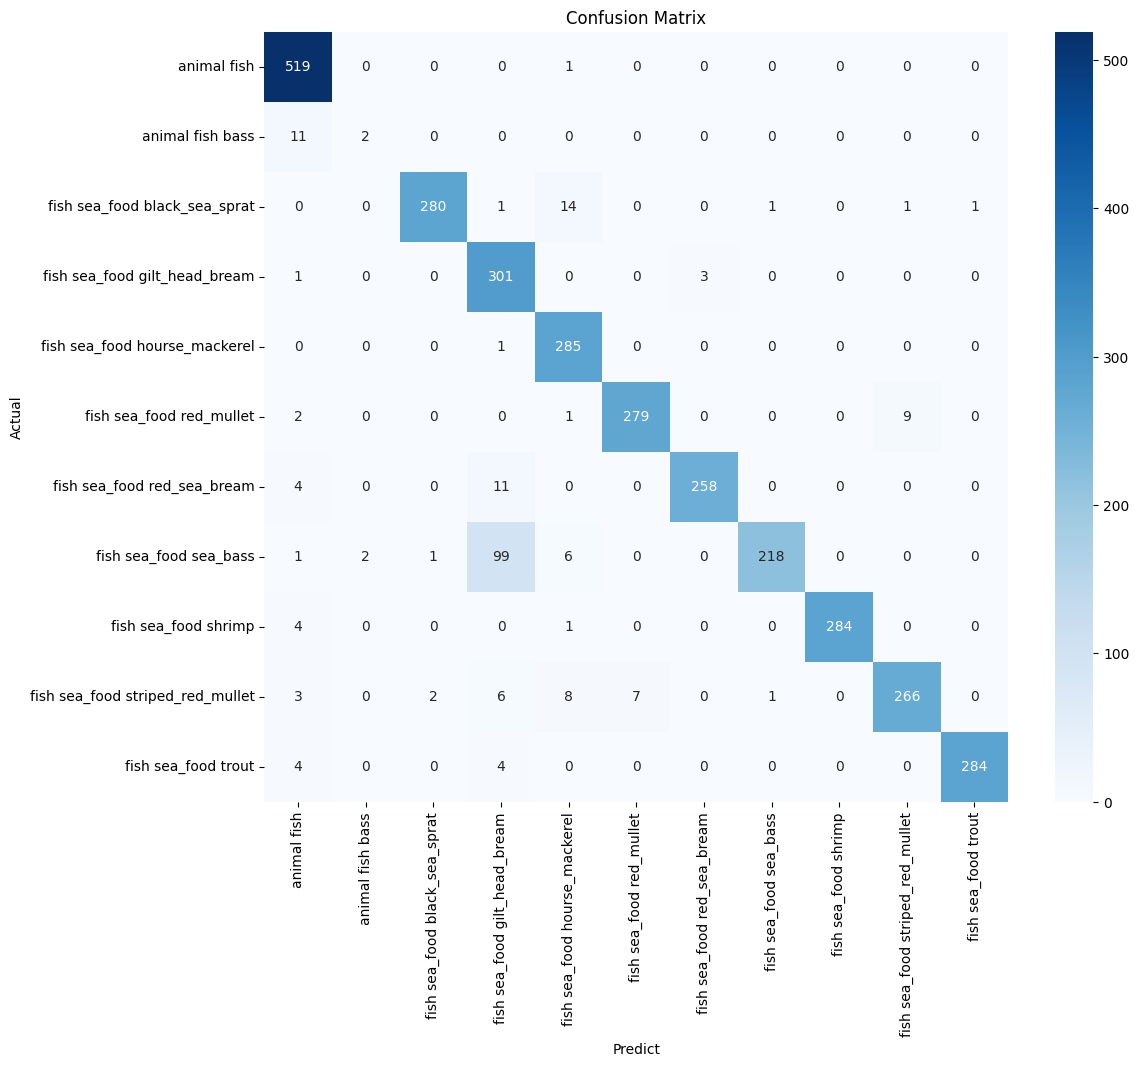

In [16]:
accuracy  = accuracy_score(y_true, y_pred)
confusion = cm(y_true, y_pred)
print("Accuracy :", accuracy)
print("confusion_matrix :", cm)
plt.figure(figsize=(12,10))
sns.heatmap(confusion,annot=True,fmt='d', cmap='Blues', xticklabels=Fish_label, yticklabels=Fish_label)
plt.ylabel("Actual")
plt.xlabel("Predict")
plt.title("Confusion Matrix")
plt.show() 

In [17]:
#  pretrained ResNet50
model = models.resnet50(pretrained = True)
for i in model.parameters():
    i.requires_grad = False # Freeze
# modify the last layer of VGG16
model.fc = nn.Linear(model.fc.in_features, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
# Training
epochs = 2
for epoch in range(epochs):
  for images_as_tensor_values, actual_labels in train_loader:
      optimizer.zero_grad()
      predicted_labels = model(images_as_tensor_values) # predicted_labels=0-9
      loss = criterion(predicted_labels, actual_labels)
      loss.backward()
      optimizer.step()
  print('Epoch = ', epoch, 'Loss = ', loss.item())


C:\Users\D E L L\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\D E L L\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch =  0 Loss =  0.2545975148677826
Epoch =  1 Loss =  0.31645467877388


In [18]:
# Evaluation for pretrained model ResNet50
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)
        _,predicted = torch.max(outputs,1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())


In [19]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=Fish_label
))

                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      1.00       520
                animal fish bass       1.00      0.77      0.87        13
   fish sea_food black_sea_sprat       1.00      0.98      0.99       298
   fish sea_food gilt_head_bream       0.97      0.94      0.96       305
   fish sea_food hourse_mackerel       0.91      1.00      0.95       286
        fish sea_food red_mullet       0.97      1.00      0.98       291
     fish sea_food red_sea_bream       0.96      0.99      0.98       273
          fish sea_food sea_bass       0.96      0.98      0.97       327
            fish sea_food shrimp       1.00      0.99      0.99       289
fish sea_food striped_red_mullet       1.00      0.90      0.95       293
             fish sea_food trout       1.00      0.97      0.98       292

                        accuracy                           0.98      3187
                       macro avg    

Accuracy : 0.9755255726388453
confusion_matrix : <function confusion_matrix at 0x000002B5B67C3EC0>


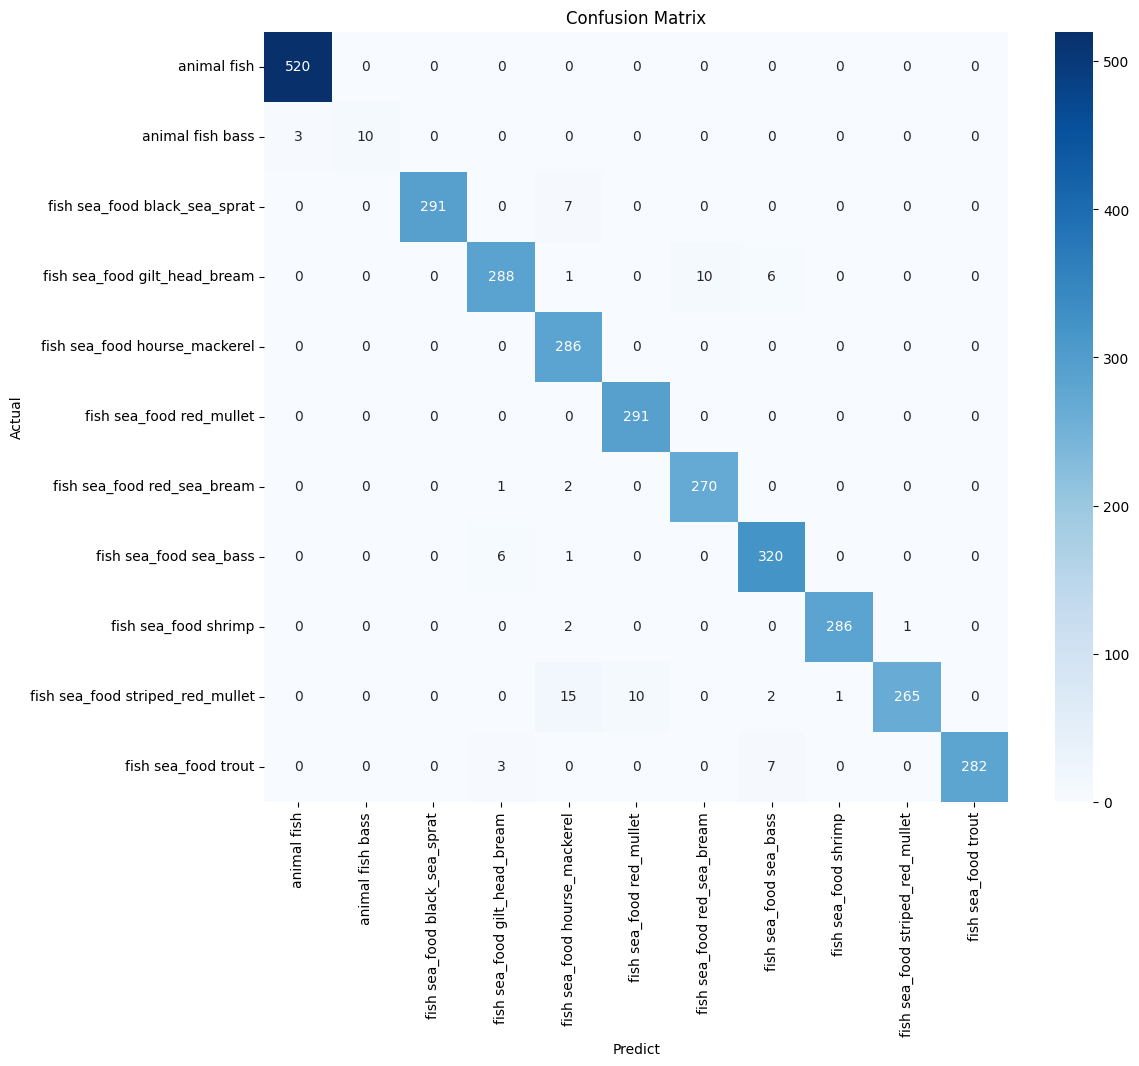

In [20]:
accuracy  = accuracy_score(y_true, y_pred)
confusion = cm(y_true, y_pred)
print("Accuracy :", accuracy)
print("confusion_matrix :", cm)
plt.figure(figsize=(12,10))
sns.heatmap(confusion,annot=True,fmt='d', cmap='Blues', xticklabels=Fish_label, yticklabels=Fish_label)
plt.ylabel("Actual")
plt.xlabel("Predict")
plt.title("Confusion Matrix")
plt.show() 

In [9]:
#  pretrained MobileNetV2
model = models.mobilenet_v2(pretrained = True)
for i in model.features.parameters():
    i.requires_grad = False # Freeze
# modify the last layer of VGG16
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
# Training
epochs = 2
for epoch in range(epochs):
  for images_as_tensor_values, actual_labels in train_loader:
      optimizer.zero_grad()
      predicted_labels = model(images_as_tensor_values) # predicted_labels=0-9
      loss = criterion(predicted_labels, actual_labels)
      loss.backward()
      optimizer.step()
  print('Epoch = ', epoch, 'Loss = ', loss.item())


C:\Users\D E L L\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\D E L L\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch =  0 Loss =  0.2718718945980072
Epoch =  1 Loss =  0.18725763261318207


In [10]:
# Evaluation for pretrained model MobileNetV2
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)
        _,predicted = torch.max(outputs,1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())


In [11]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=Fish_label
))


                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      0.99       520
                animal fish bass       1.00      0.46      0.63        13
   fish sea_food black_sea_sprat       0.97      1.00      0.99       298
   fish sea_food gilt_head_bream       0.94      0.99      0.97       305
   fish sea_food hourse_mackerel       1.00      0.99      1.00       286
        fish sea_food red_mullet       0.99      1.00      1.00       291
     fish sea_food red_sea_bream       0.99      0.99      0.99       273
          fish sea_food sea_bass       0.98      0.95      0.96       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       0.99      0.99      0.99       293
             fish sea_food trout       1.00      0.95      0.97       292

                        accuracy                           0.98      3187
                       macro avg    

confusion_matrix : <function confusion_matrix at 0x000002B5B67C3EC0>


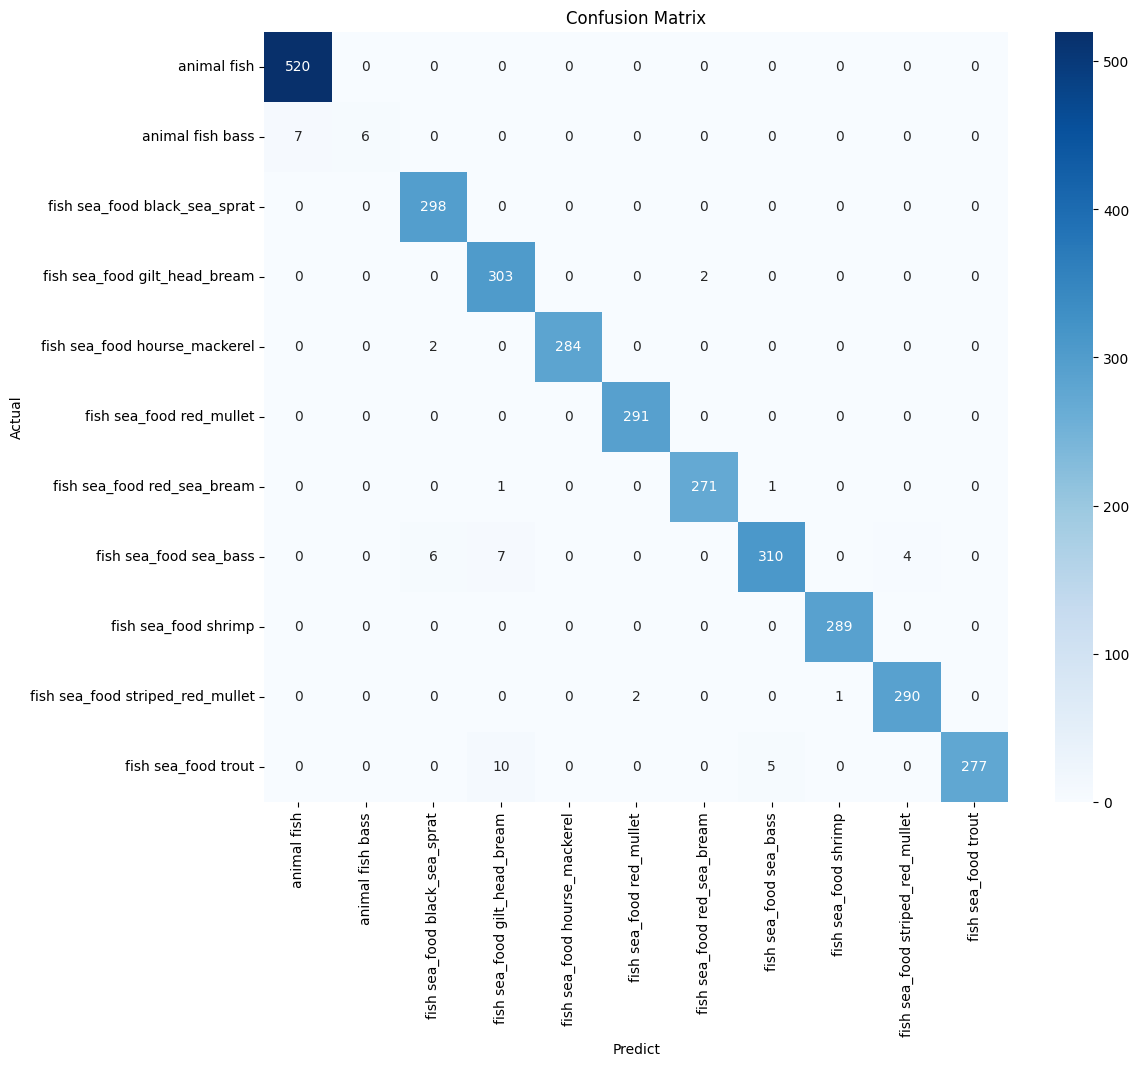

In [12]:
confusion = cm(y_true, y_pred)
print("confusion_matrix :", cm)
plt.figure(figsize=(12,10))
sns.heatmap(confusion,annot=True,fmt='d', cmap='Blues', xticklabels=Fish_label, yticklabels=Fish_label)
plt.ylabel("Actual")
plt.xlabel("Predict")
plt.title("Confusion Matrix")
plt.show() 

In [21]:
# Pretrained EfficientNetB0
model = models.efficientnet_b0(pretrained = True)
for i in model.features.parameters():
    i.requires_grad = False # Freeze
# modify the last layer of VGG16
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
# Training
epochs = 2
for epoch in range(epochs):
  for images_as_tensor_values, actual_labels in train_loader:
      optimizer.zero_grad()
      predicted_labels = model(images_as_tensor_values) # predicted_labels=0-9
      loss = criterion(predicted_labels, actual_labels)
      loss.backward()
      optimizer.step()
  print('Epoch = ', epoch, 'Loss = ', loss.item())



C:\Users\D E L L\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\D E L L\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch =  0 Loss =  0.4659276306629181
Epoch =  1 Loss =  0.4817318022251129


In [50]:
# Evaluation for pretrained model MobileNetV2
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)
        _,predicted = torch.max(outputs,1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())


Accuracy : 0.9874490116096643
Precision: 0.9890872330636252
Recall   : 0.9214176607262187
F1-score : 0.9333336760300516
confusion_matrix : <function confusion_matrix at 0x0000026EBCA744A0>


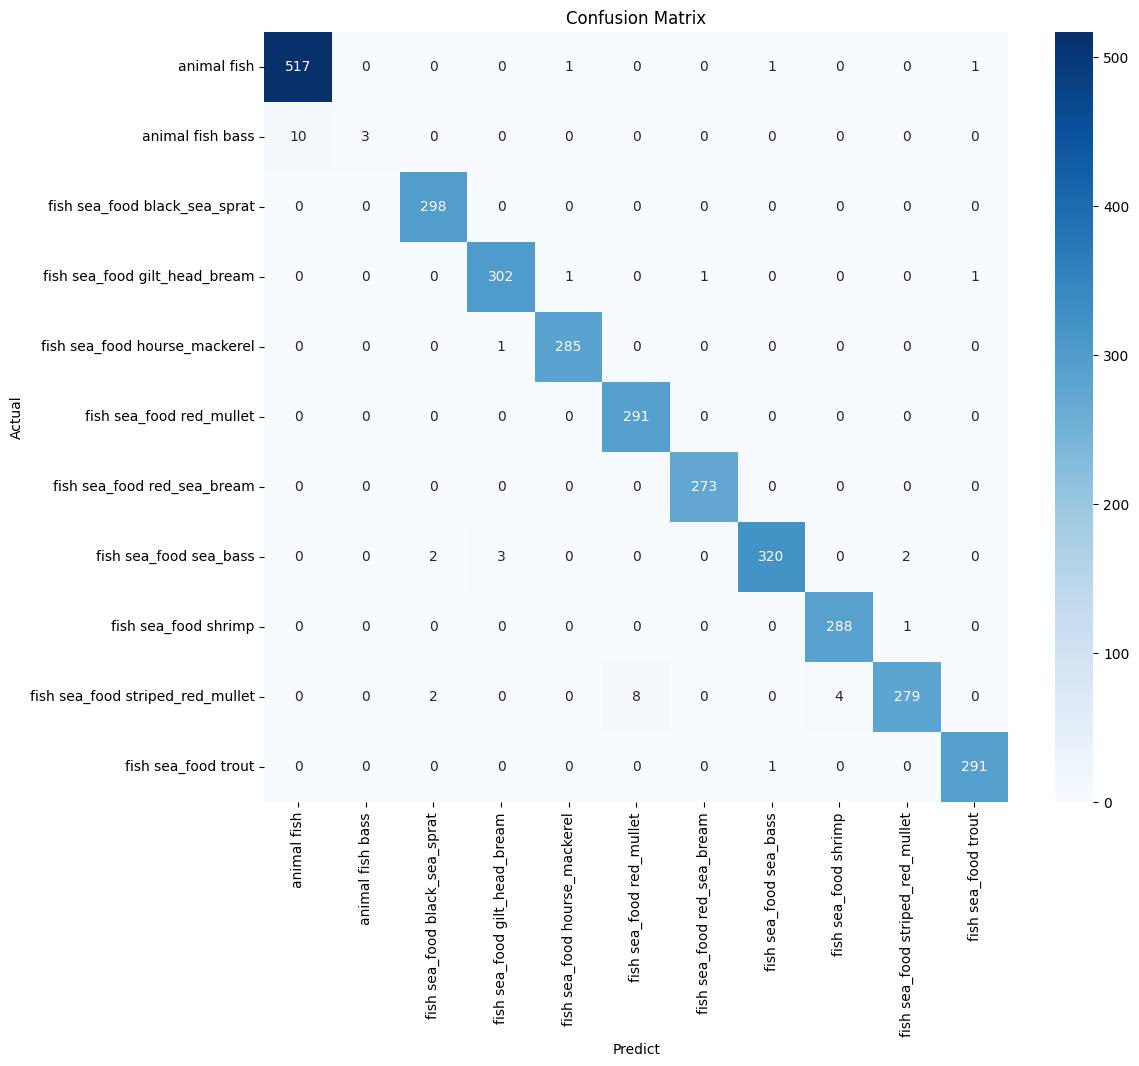

In [ ]:
accuracy  = accuracy_score(y_true, y_pred)
confusion = cm(y_true, y_pred)
print("Accuracy :", accuracy)
print("confusion_matrix :", cm)
plt.figure(figsize=(12,10))
sns.heatmap(confusion,annot=True,fmt='d', cmap='Blues', xticklabels=Fish_label, yticklabels=Fish_label)
plt.ylabel("Actual")
plt.xlabel("Predict")
plt.title("Confusion Matrix")
plt.show() 